In [1]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        # Derivative of z = x + y with respect to x is 1, and with respect to y is also 1.
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        # Derivative of z = x * y with respect to x is y, and with respect to y is x.
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f"**{other}")

        # Derivative of z = x^n with respect to x is n * x^(n-1).
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad

        out._backward = _backward

        return out

    # a / b = a * (1 / b) = a * b**(-1)
    def __truediv__(self, other):  # self / other
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        # Derivative of z = exp(x) with respect to x is exp(x).
        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        # Derivative of z = tanh(x) with respect to x is 1 - tanh^2(x).
        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [4]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(numpy.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(numpy.random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b, where w * x is the dot product of w and x
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

In [5]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

In [6]:
# MLP = Multi-Layer Perceptron
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        # return [p for layer in self.layers for p in layer.parameters()]
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [7]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

mlp = MLP(3, [4, 4, 1])

In [8]:
for k in range(5000):
    # forward pass
    ypred = [mlp(x) for x in xs]

    # compute the loss (mean squared error)
    loss = sum((yp - y) ** 2 for yp, y in zip(ypred, ys)) * (1.0 / len(ys))

    # backward pass
    for p in mlp.parameters():
        p.grad = 0.0
    loss.backward()

    # update parameters using gradient descent
    for p in mlp.parameters():
        p.data += -0.1 * p.grad

    print(f"epoch: {k:4d}, loss: {loss.data:.20f}, ypred: {[yp.data for yp in ypred]}")

    if math.isclose(loss.data, 0.0, rel_tol=1e-2):
        break

epoch:    0, loss: 1.09877488584011828721, ypred: [-0.4727765952878751, -0.07991049040322745, -0.22654232734898605, 0.11612944008753444]
epoch:    1, loss: 0.58308535709417097515, ypred: [0.04149715010870561, -0.36316722935340207, -0.14047176073992595, 0.4810886942145071]
epoch:    2, loss: 0.34065667593503218269, ypred: [0.35086922315172253, -0.548634775718157, -0.2411464228913047, 0.5979221205950029]
epoch:    3, loss: 0.22050154434970012374, ypred: [0.47000541236914284, -0.6539432542828876, -0.4155810508734184, 0.6260867278014033]
epoch:    4, loss: 0.15535744112263005778, ypred: [0.5668627962709119, -0.7113107300076957, -0.5148407234882187, 0.6607347512017447]
epoch:    5, loss: 0.11713606097570497533, ypred: [0.6322140883630124, -0.7483803873447059, -0.584394255689722, 0.6881711961225047]
epoch:    6, loss: 0.09283961390950989934, ypred: [0.6791858468439406, -0.7743168157269912, -0.6338220729012013, 0.7111790159721388]
epoch:    7, loss: 0.07630778944878485737, ypred: [0.714264788

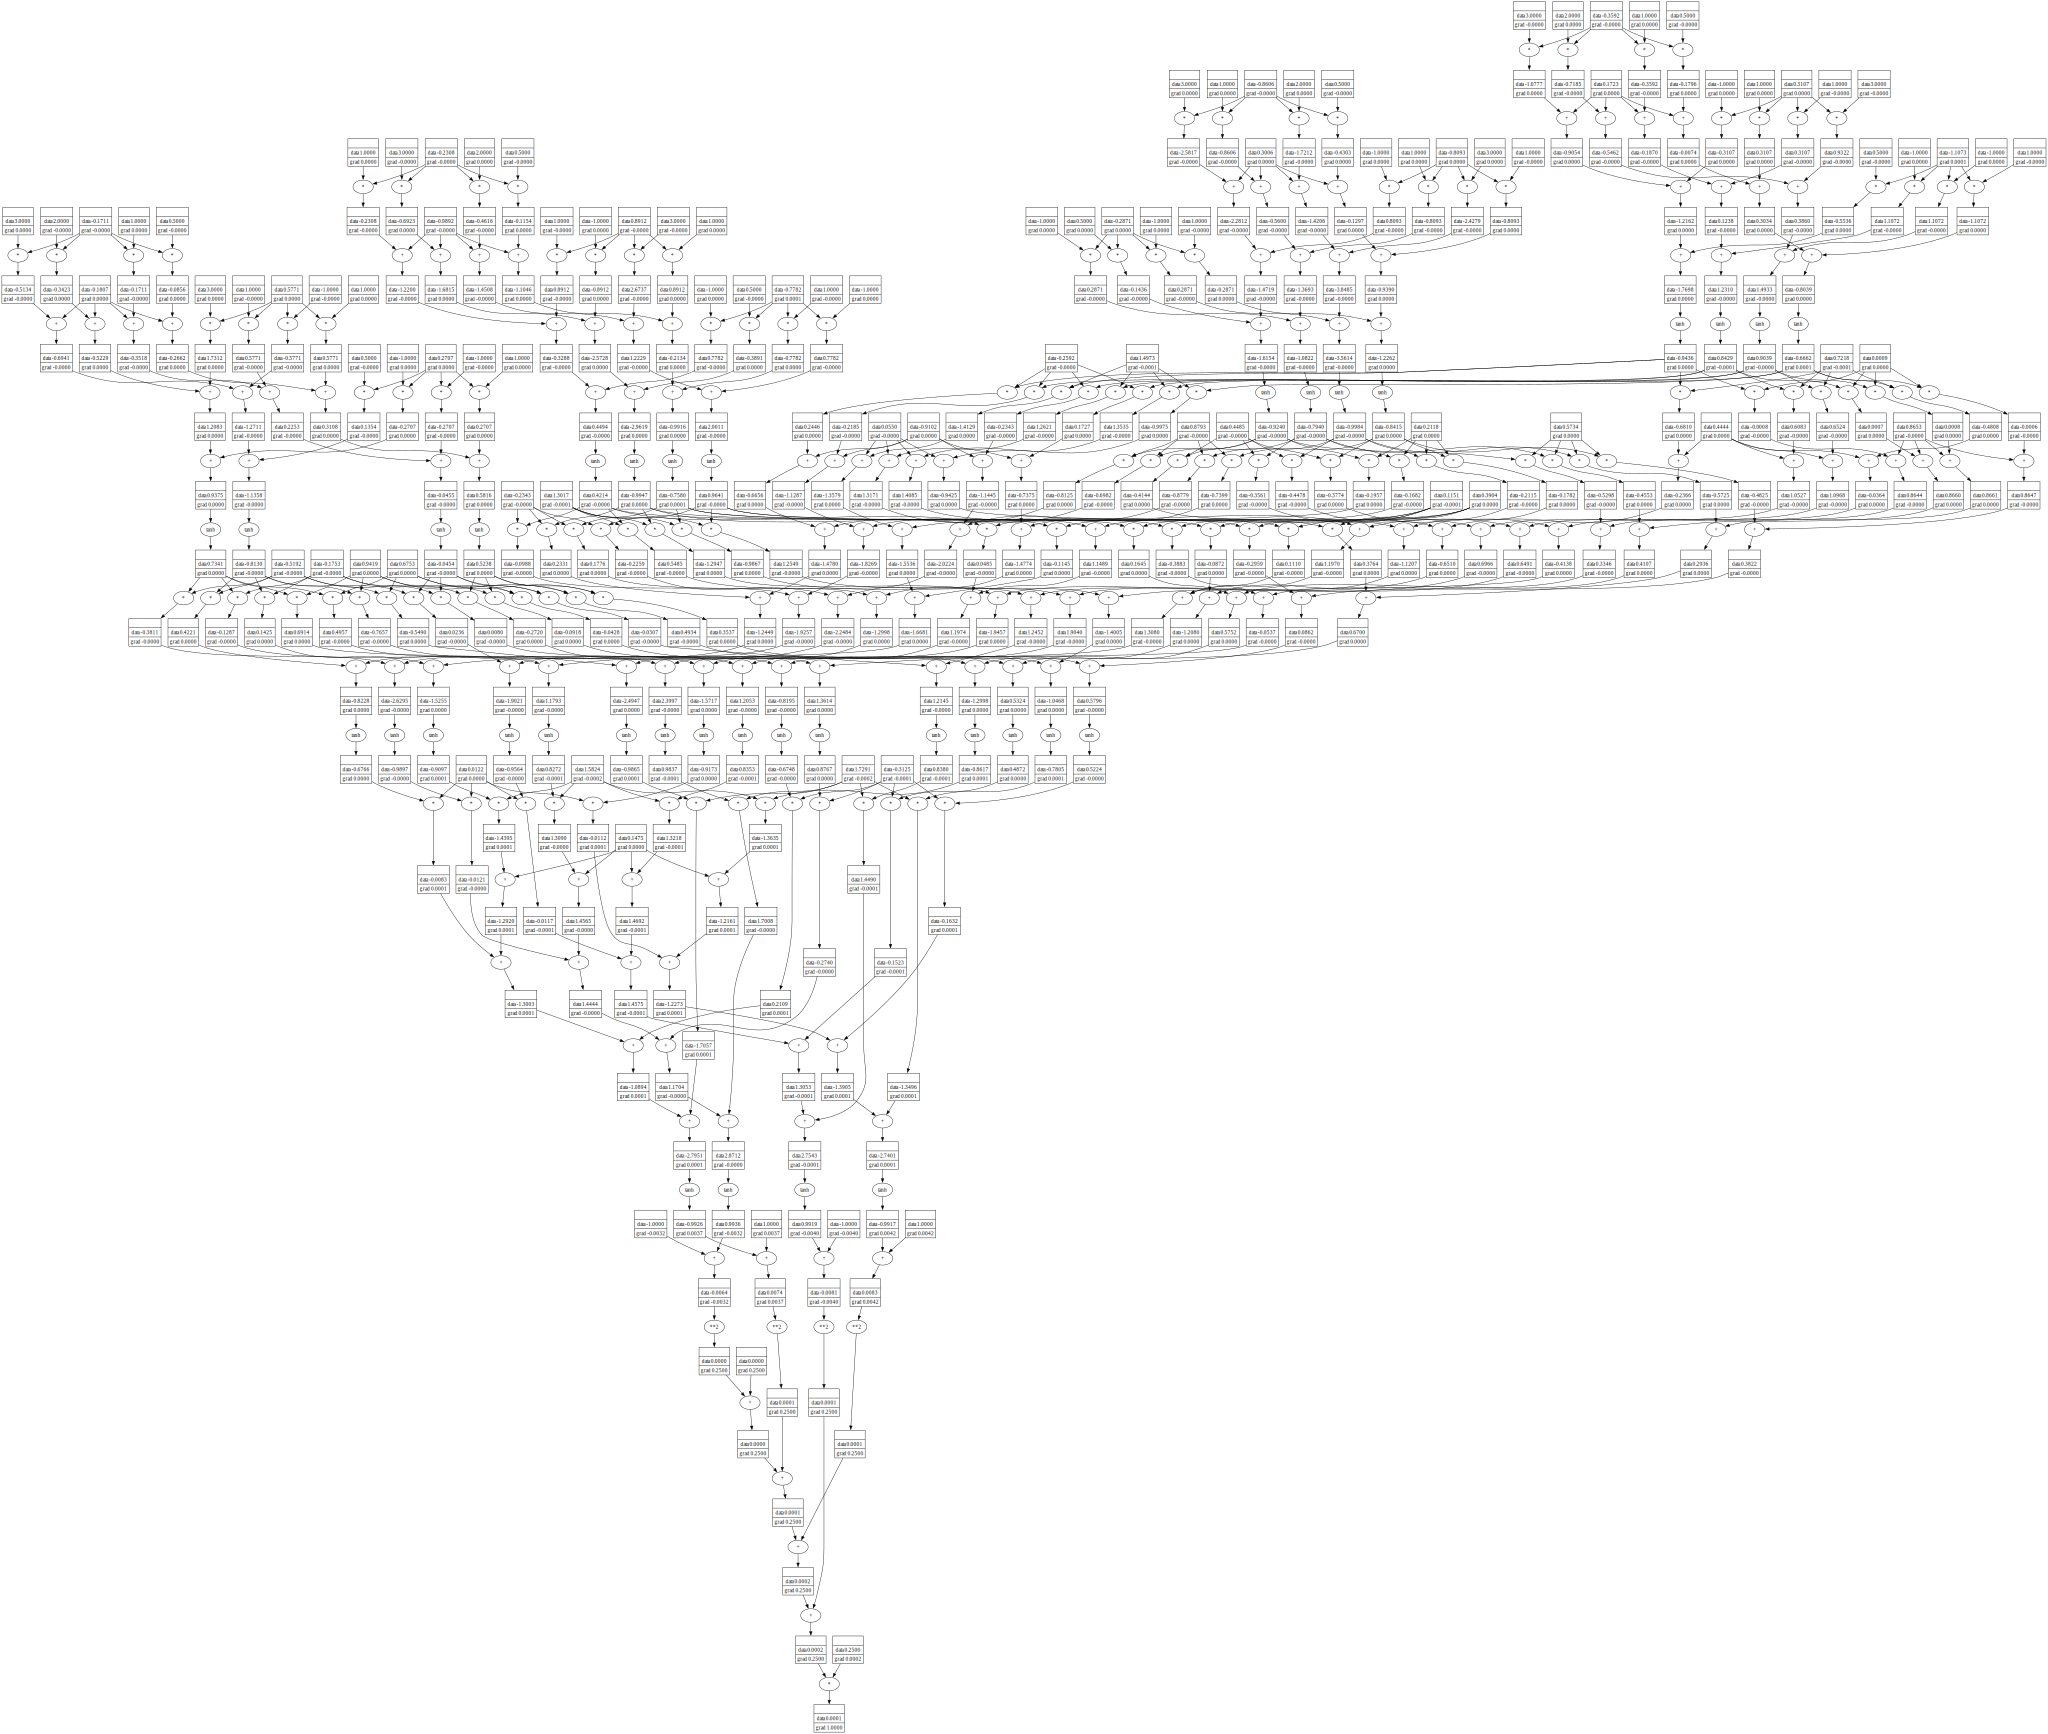

In [9]:
draw_dot(loss, rankdir="TB")